# Urban Fraction — ESA WorldCover (GEE)

**Product:** `ESA/WorldCover/v200` (2021, 10m resolution)  
**Band:** `Map` — land cover classification  
**Class 50:** Built-up (đô thị/xây dựng)  
**Method:** GEE Python API — tính tỷ lệ pixel Built-up trong buffer quanh 6 trạm Hà Nội  

**Đây là đặc trưng tĩnh** (static) — mỗi trạm có 1 giá trị, không thay đổi theo thời gian.  
Kết quả lưu vào `data/processed/station_spatial_features.csv`.

**Các lớp ESA WorldCover:**
| Giá trị | Lớp |
|---------|-----|
| 10 | Tree cover |
| 20 | Shrubland |
| 30 | Grassland |
| 40 | Cropland |
| **50** | **Built-up** |
| 60 | Bare/sparse vegetation |
| 70 | Snow and ice |
| 80 | Permanent water bodies |
| 90 | Herbaceous wetland |
| 95 | Mangroves |
| 100 | Moss and lichen |

**Setup một lần:**
1. Có tài khoản Google — đăng ký GEE miễn phí: https://earthengine.google.com/
2. `pip install earthengine-api geemap`
3. `earthengine authenticate` (chạy trong terminal, 1 lần)

## Cell 1 — Cài đặt

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'earthengine-api', 'geemap'])
print('earthengine-api + geemap ready.')

earthengine-api + geemap ready.


## Cell 2 — Authenticate & Initialize GEE

In [2]:
import ee

# Điền project ID tại: https://console.cloud.google.com/
GEE_PROJECT = "silken-gadget-419107"   # thay bằng project ID của bạn

try:
    ee.Initialize(project=GEE_PROJECT)
    print("GEE initialized OK.")
except ee.EEException:
    print("Chưa có credentials. Chạy: earthengine authenticate")
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print("GEE initialized OK (after auth).")

# Kiểm tra collection tồn tại
img = ee.ImageCollection("ESA/WorldCover/v200").first()
info = img.getInfo()
print(f"ESA WorldCover bands: {[b['id'] for b in info['bands']]}")
print(f"Date: {info['properties']['system:index']}  → collection OK")

GEE initialized OK.


ESA WorldCover bands: ['Map']
Date: 2021  → collection OK


## Cell 3 — Cấu hình trạm & tham số

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT      = Path('D:/Bussiness_plan/Multimodal_PM25')
PROC_DIR  = ROOT / 'data/processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV   = PROC_DIR / 'station_spatial_features.csv'
MERGED    = PROC_DIR / 'daily_merged.csv'

# 6 trạm Hà Nội
STATIONS = {
    2161292: {'lat': 21.0152, 'lon': 105.7999, 'name': 'Phố Lưu Quang Vũ'},
    2161306: {'lat': 21.0500, 'lon': 105.7400, 'name': 'Minh Khai - Bắc Từ Liêm'},
    4946811: {'lat': 21.0491, 'lon': 105.8831, 'name': 'Trạm 4946811'},
    4946812: {'lat': 21.0031, 'lon': 105.7947, 'name': 'Trạm 4946812'},
    4946813: {'lat': 21.0052, 'lon': 105.8418, 'name': 'Trạm 4946813'},
    6123215: {'lat': 20.9933, 'lon': 105.9441, 'name': 'Trạm 6123215'},
}

# Buffer sizes để so sánh (meters)
BUFFER_SIZES_M = [500, 1000, 2000, 5000]

# ESA WorldCover class values
LC_CLASSES = {
    'tree':        10,
    'shrubland':   20,
    'grassland':   30,
    'cropland':    40,
    'built_up':    50,   # ← mục tiêu chính
    'bare':        60,
    'water':       80,
}

print(f"Số trạm: {len(STATIONS)}")
print(f"Buffer sizes: {BUFFER_SIZES_M} m")
for sid, s in STATIONS.items():
    print(f"  {sid}: ({s['lat']:.4f}, {s['lon']:.4f}) — {s['name']}")

Số trạm: 6
Buffer sizes: [500, 1000, 2000, 5000] m
  2161292: (21.0152, 105.7999) — Phố Lưu Quang Vũ
  2161306: (21.0500, 105.7400) — Minh Khai - Bắc Từ Liêm
  4946811: (21.0491, 105.8831) — Trạm 4946811
  4946812: (21.0031, 105.7947) — Trạm 4946812
  4946813: (21.0052, 105.8418) — Trạm 4946813
  6123215: (20.9933, 105.9441) — Trạm 6123215


## Cell 4 — Hàm extract land cover fraction

Tính tỷ lệ pixel của mỗi lớp trong buffer quanh trạm.  
`urban_fraction = n_built_up_pixels / total_pixels_in_buffer`

In [4]:
# Load ESA WorldCover 2021
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map")

def extract_lc_fractions(lat, lon, buffer_m):
    """
    Trả về dict chứa fraction của mỗi lớp land cover trong buffer.
    fraction = n_pixels_class / total_pixels_in_buffer
    """
    point  = ee.Geometry.Point([lon, lat])
    region = point.buffer(buffer_m)

    # Đếm tổng pixel
    total = worldcover.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region,
        scale=10,          # WorldCover native resolution
        maxPixels=1e7
    ).get('Map').getInfo()

    if total is None or total == 0:
        return {f'{cls}_frac': None for cls in LC_CLASSES}

    result = {}
    for cls_name, cls_val in LC_CLASSES.items():
        # Mask pixels = cls_val, đếm số pixel đó
        cls_count = worldcover.eq(cls_val).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=region,
            scale=10,
            maxPixels=1e7
        ).get('Map').getInfo()

        result[f'{cls_name}_frac'] = round(cls_count / total, 4) if cls_count is not None else 0.0

    result['total_pixels'] = int(total)
    return result


# Quick test — trạm 2161292
test = extract_lc_fractions(21.0152, 105.7999, buffer_m=2000)
print("Test (station 2161292, buffer 2km):")
for k, v in test.items():
    print(f"  {k}: {v}")

Test (station 2161292, buffer 2km):
  tree_frac: 0.1317
  shrubland_frac: 0.0
  grassland_frac: 0.0075
  cropland_frac: 0.0061
  built_up_frac: 0.8016
  bare_frac: 0.0171
  water_frac: 0.0359
  total_pixels: 133315


## Cell 5 — Extract tất cả trạm × tất cả buffer sizes

> 6 trạm × 4 buffer sizes × 7 lớp ≈ 168 GEE calls → **~3–5 phút**

In [5]:
import time

rows = []

for sid, sinfo in STATIONS.items():
    lat, lon = sinfo['lat'], sinfo['lon']
    print(f"\nStation {sid} ({sinfo['name']})...")

    row = {
        'location_id': sid,
        'latitude':    lat,
        'longitude':   lon,
        'station_name': sinfo['name'],
    }

    for buf_m in BUFFER_SIZES_M:
        for attempt in range(3):
            try:
                fracs = extract_lc_fractions(lat, lon, buffer_m=buf_m)
                # Prefix với buffer size
                suffix = f"_{buf_m//1000}km" if buf_m >= 1000 else f"_{buf_m}m"
                for k, v in fracs.items():
                    row[f"{k}{suffix}"] = v
                print(f"  buffer {buf_m}m → urban={fracs.get('built_up_frac', 'N/A'):.3f}  "
                      f"tree={fracs.get('tree_frac', 'N/A'):.3f}  "
                      f"pixels={fracs.get('total_pixels', 0):,}")
                break
            except Exception as e:
                if attempt == 2:
                    print(f"  FAILED buffer {buf_m}m: {e}")
                    suffix = f"_{buf_m//1000}km" if buf_m >= 1000 else f"_{buf_m}m"
                    for cls_name in LC_CLASSES:
                        row[f"{cls_name}_frac{suffix}"] = None
                else:
                    time.sleep(5)

    rows.append(row)

df_spatial = pd.DataFrame(rows)
print(f"\nShape: {df_spatial.shape}")
print(df_spatial[['location_id'] + [c for c in df_spatial.columns if 'built_up' in c]].to_string(index=False))


Station 2161292 (Phố Lưu Quang Vũ)...


  buffer 500m → urban=0.849  tree=0.130  pixels=8,318


  buffer 1000m → urban=0.837  tree=0.123  pixels=33,325


  buffer 2000m → urban=0.802  tree=0.132  pixels=133,315


  buffer 5000m → urban=0.714  tree=0.162  pixels=833,253

Station 2161306 (Minh Khai - Bắc Từ Liêm)...


...

  buffer 5000m → urban=0.676  tree=0.166  pixels=833,123

Station 6123215 (Trạm 6123215)...


  buffer 500m → urban=0.637  tree=0.078  pixels=8,323


  buffer 1000m → urban=0.479  tree=0.087  pixels=33,335


  buffer 2000m → urban=0.386  tree=0.269  pixels=133,309


  buffer 5000m → urban=0.352  tree=0.364  pixels=833,135

Shape: (6, 36)
 location_id  built_up_frac_500m  built_up_frac_1km  built_up_frac_2km  built_up_frac_5km
     2161292              0.8486             0.8368             0.8016             0.7144
     2161306              0.8278             0.6439             0.5040             0.4255
     4946811              0.7791             0.6817             0.6420             0.4427
     4946812              0.6462             0.6759             0.7466             0.7220
     4946813              0.8188             0.7995             0.8540             0.6763
     6123215              0.6373             0.4795             0.3863             0.3525


## Cell 6 — Lưu kết quả

In [6]:
# Nếu file đã tồn tại (từ osmnx / WorldPop), merge thêm cột mới
if OUT_CSV.exists():
    df_existing = pd.read_csv(OUT_CSV)
    new_cols = [c for c in df_spatial.columns if c not in df_existing.columns]
    if new_cols:
        df_spatial_merge = df_spatial[['location_id'] + new_cols]
        df_out = df_existing.merge(df_spatial_merge, on='location_id', how='left')
        print(f"Merged {len(new_cols)} new cols into existing file")
    else:
        # Update existing urban columns
        drop_cols = [c for c in df_existing.columns if any(
            cls in c for cls in list(LC_CLASSES.keys()) + ['total_pixels']
        )]
        df_existing.drop(columns=drop_cols, inplace=True)
        df_out = df_existing.merge(
            df_spatial[['location_id'] + [c for c in df_spatial.columns if c != 'location_id']],
            on='location_id', how='left'
        )
        print(f"Updated existing land cover columns")
else:
    df_out = df_spatial
    print(f"Created new file")

df_out.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}")
print(f"Shape: {df_out.shape}")
print(df_out.to_string(index=False))

Updated existing land cover columns
Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\station_spatial_features.csv
Shape: (6, 60)
 location_id  latitude_x  longitude_x          station_name_x  dist_motorway_m  dist_primary_m  dist_secondary_m  dist_any_major_m  road_density_1km  road_density_2km  n_major_edges_5km  ndvi_buffer_500m  ndvi_buffer_500m_std  ndvi_buffer_500m_p10  ndvi_buffer_500m_p90  ndvi_buffer_1km  ndvi_buffer_1km_std  ndvi_buffer_1km_p10  ndvi_buffer_1km_p90  ndvi_buffer_2km  ndvi_buffer_2km_std  ndvi_buffer_2km_p10  ndvi_buffer_2km_p90  ndvi_buffer_1km_winter  ndvi_buffer_1km_summer  latitude_y  longitude_y          station_name_y  tree_frac_500m  shrubland_frac_500m  grassland_frac_500m  cropland_frac_500m  built_up_frac_500m  bare_frac_500m  water_frac_500m  total_pixels_500m  tree_frac_1km  shrubland_frac_1km  grassland_frac_1km  cropland_frac_1km  built_up_frac_1km  bare_frac_1km  water_frac_1km  total_pixels_1km  tree_frac_2km  shrubland_frac_2km  grassland

## Cell 7 — Visualize: Bản đồ land cover quanh trạm

Dùng `geemap` để hiển thị ESA WorldCover và các buffer trực quan.

In [7]:
import geemap

# Palette chính thức của ESA WorldCover
WC_VIS = {
    'min': 10, 'max': 100,
    'palette': [
        '006400',  # 10 Tree cover
        'ffbb22',  # 20 Shrubland
        'ffff4c',  # 30 Grassland
        'f096ff',  # 40 Cropland
        'fa0000',  # 50 Built-up  ← đỏ = đô thị
        'b4b4b4',  # 60 Bare/sparse
        'f0f0f0',  # 70 Snow/ice
        '0064c8',  # 80 Water
        '0096a0',  # 90 Wetland
        '00cf75',  # 95 Mangroves
        'fae6a0',  # 100 Moss/lichen
    ]
}

# Tâm Hà Nội
Map = geemap.Map(center=[21.02, 105.83], zoom=11)
Map.addLayer(worldcover, WC_VIS, 'ESA WorldCover 2021')

# Vẽ buffer 2km quanh mỗi trạm
for sid, sinfo in STATIONS.items():
    pt  = ee.Geometry.Point([sinfo['lon'], sinfo['lat']])
    buf = pt.buffer(2000)
    Map.addLayer(
        ee.FeatureCollection([ee.Feature(buf)]),
        {'color': 'yellow', 'fillColor': '00000000', 'width': 2},
        f'Buffer 2km — {sid}'
    )
    Map.addLayer(
        ee.FeatureCollection([ee.Feature(pt)]),
        {'color': 'cyan', 'pointRadius': 5},
        f'Station {sid}'
    )

# Legend
legend_dict = {
    'Tree cover': '006400',
    'Cropland': 'f096ff',
    'Built-up (Urban)': 'fa0000',
    'Bare/sparse': 'b4b4b4',
    'Water': '0064c8',
}
Map.add_legend(title='ESA WorldCover', legend_dict=legend_dict)

Map

Map(center=[21.02, 105.83], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Cell 8 — Biểu đồ so sánh urban fraction giữa các trạm

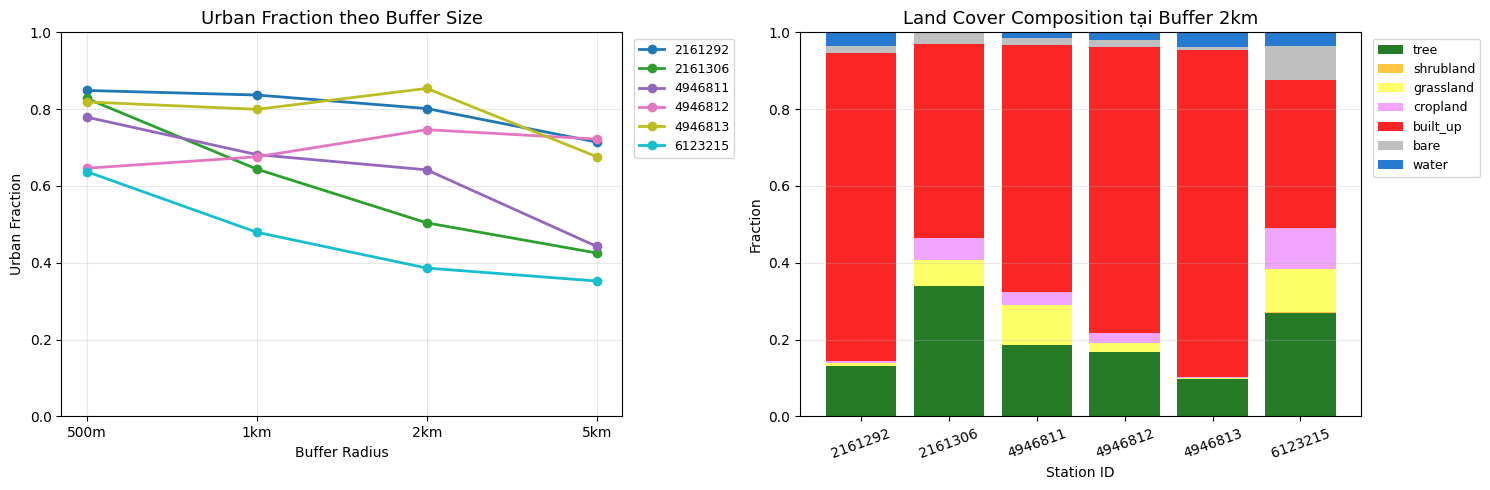

Saved: D:\Bussiness_plan\Multimodal_PM25\outputs\urban_fraction_worldcover.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Lấy urban fraction tại 4 buffer sizes cho mỗi trạm
buf_labels = ['500m', '1km', '2km', '5km']
buf_cols   = ['built_up_frac_500m', 'built_up_frac_1km', 'built_up_frac_2km', 'built_up_frac_5km']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Urban fraction theo buffer size
colors = plt.cm.tab10(np.linspace(0, 1, len(STATIONS)))
for i, (sid, sinfo) in enumerate(STATIONS.items()):
    row = df_out[df_out['location_id'] == sid].iloc[0]
    vals = [row.get(c, 0) for c in buf_cols]
    axes[0].plot(buf_labels, vals, marker='o', label=f"{sid}", color=colors[i], linewidth=2)

axes[0].set_title('Urban Fraction theo Buffer Size', fontsize=13)
axes[0].set_ylabel('Urban Fraction')
axes[0].set_xlabel('Buffer Radius')
axes[0].legend(fontsize=9, bbox_to_anchor=(1.01, 1))
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot 2: Stacked bar — land cover composition tại buffer 2km
lc_cols_2km = {cls: f'{cls}_frac_2km' for cls in LC_CLASSES if f'{cls}_frac_2km' in df_out.columns}
lc_colors = {
    'tree': '#006400', 'shrubland': '#ffbb22', 'grassland': '#ffff4c',
    'cropland': '#f096ff', 'built_up': '#fa0000',
    'bare': '#b4b4b4', 'water': '#0064c8'
}

station_ids = [str(sid) for sid in STATIONS.keys()]
bottom = np.zeros(len(STATIONS))

for cls_name, col in lc_cols_2km.items():
    vals = [float(df_out[df_out['location_id'] == sid][col].iloc[0] or 0)
            for sid in STATIONS.keys()]
    axes[1].bar(station_ids, vals, bottom=bottom, label=cls_name,
                color=lc_colors.get(cls_name, 'gray'), alpha=0.85)
    bottom += np.array(vals)

axes[1].set_title('Land Cover Composition tại Buffer 2km', fontsize=13)
axes[1].set_ylabel('Fraction')
axes[1].set_xlabel('Station ID')
axes[1].legend(fontsize=9, bbox_to_anchor=(1.01, 1))
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
out_fig = ROOT / 'outputs/urban_fraction_worldcover.png'
out_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_fig, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {out_fig}")

## Cell 9 — Chọn buffer size tối ưu để dùng trong model

In [9]:
# So sánh variance của urban_fraction giữa các trạm theo từng buffer size
# Buffer size tốt nhất = phân biệt rõ nhất giữa các trạm (variance cao)

print("Urban fraction tại từng buffer size:")
print("-" * 60)

best_buf = None
best_var = -1

for buf_m, buf_label in zip(BUFFER_SIZES_M, ['500m', '1km', '2km', '5km']):
    suffix = f"_500m" if buf_m == 500 else f"_{buf_m//1000}km"
    col = f"built_up_frac{suffix}"
    if col not in df_out.columns:
        continue
    vals = df_out[col].dropna().values
    var  = np.var(vals)
    flag = " ← BEST" if var > best_var else ""
    if var > best_var:
        best_var = var
        best_buf = col

    print(f"  {buf_label:6s}: mean={vals.mean():.3f}  std={vals.std():.3f}  "
          f"min={vals.min():.3f}  max={vals.max():.3f}  var={var:.4f}{flag}")

print(f"\n→ Khuyến nghị dùng: '{best_buf}' (phân biệt rõ nhất giữa các trạm)")
print()
print("Giá trị urban fraction tại buffer tốt nhất:")
for sid in STATIONS:
    val = df_out[df_out['location_id'] == sid][best_buf].iloc[0]
    print(f"  {sid}: {val:.3f}  ({STATIONS[sid]['name']})")

Urban fraction tại từng buffer size:
------------------------------------------------------------
  500m  : mean=0.760  std=0.086  min=0.637  max=0.849  var=0.0074 ← BEST
  1km   : mean=0.686  std=0.116  min=0.479  max=0.837  var=0.0134 ← BEST
  2km   : mean=0.656  std=0.166  min=0.386  max=0.854  var=0.0274 ← BEST
  5km   : mean=0.556  std=0.152  min=0.352  max=0.722  var=0.0231

→ Khuyến nghị dùng: 'built_up_frac_2km' (phân biệt rõ nhất giữa các trạm)

Giá trị urban fraction tại buffer tốt nhất:
  2161292: 0.802  (Phố Lưu Quang Vũ)
  2161306: 0.504  (Minh Khai - Bắc Từ Liêm)
  4946811: 0.642  (Trạm 4946811)
  4946812: 0.747  (Trạm 4946812)
  4946813: 0.854  (Trạm 4946813)
  6123215: 0.386  (Trạm 6123215)


## Cell 10 — Merge vào daily_merged.csv

Urban fraction là **static** — mỗi trạm 1 giá trị, broadcast sang tất cả các ngày.

In [10]:
main = pd.read_csv(MERGED, parse_dates=['date'])
print(f"daily_merged trước: {main.shape}")

# Chọn các cột urban/land cover cần merge
SPATIAL_MERGE_COLS = [
    'location_id',
    # Urban fraction (4 buffer sizes)
    'built_up_frac_500m', 'built_up_frac_1km', 'built_up_frac_2km', 'built_up_frac_5km',
    # Các lớp khác tại 2km (optional)
    'tree_frac_2km', 'cropland_frac_2km', 'water_frac_2km',
]
merge_cols_present = [c for c in SPATIAL_MERGE_COLS if c in df_out.columns]

# Drop cột cũ nếu đã tồn tại
drop_existing = [c for c in merge_cols_present if c in main.columns and c != 'location_id']
if drop_existing:
    main.drop(columns=drop_existing, inplace=True)
    print(f"Dropped existing cols: {drop_existing}")

main = main.merge(df_out[merge_cols_present], on='location_id', how='left')

# Kiểm tra
for col in merge_cols_present[1:]:
    if col in main.columns:
        pct = main[col].notna().mean() * 100
        print(f"  {col}: {pct:.0f}% filled")

main.to_csv(MERGED, index=False)
print(f"\nUpdated: {MERGED}  shape={main.shape}")

daily_merged trước: (2566, 110)
Dropped existing cols: ['built_up_frac_500m', 'built_up_frac_1km', 'built_up_frac_2km', 'built_up_frac_5km', 'tree_frac_2km', 'cropland_frac_2km', 'water_frac_2km']
  built_up_frac_500m: 100% filled
  built_up_frac_1km: 100% filled
  built_up_frac_2km: 100% filled
  built_up_frac_5km: 100% filled
  tree_frac_2km: 100% filled
  cropland_frac_2km: 100% filled
  water_frac_2km: 100% filled



Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2566, 110)


## Cell 11 — Thêm vào train_3d_v2.py

Thêm các cột urban fraction vào `tab_cols` trong `scripts/train_3d_v2.py`:

```python
# Trong tab_cols, thêm:
+ ["built_up_frac_500m", "built_up_frac_1km",
   "built_up_frac_2km", "built_up_frac_5km",
   "tree_frac_2km", "cropland_frac_2km"]
```

Sau đó xóa cache để train lại với đặc trưng mới:

```python
import shutil
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
```

**Lưu ý:** Urban fraction là đặc trưng **tĩnh** — giá trị không đổi theo thời gian nhưng khác nhau giữa các trạm.  
Mô hình cây sẽ dùng nó như một proxy cho "môi trường đô thị" quanh trạm,  
giúp phân biệt trạm ở khu vực mật độ cao vs. ngoại ô.

In [11]:
import shutil
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)